In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("aircraft_price.csv")

In [4]:
df.head()

,model_name,engine_type,engine_power,max_speed,cruise_speed,stall_speed,fuel_tank,all_eng_roc,out_eng_roc,takeoff_distance,landing_distance,empty_weight,length,wing_span,range,price
0,100 Darter (S.L. Industries),Piston,145.0,104.0,91.0,46.0,36.0,450.0,900.0,1300.0,2050.0,1180.0,303.0,449.0,370.0,1300000.0
1,7 CCM Champ,Piston,85.0,89.0,83.0,44.0,15.0,600.0,720.0,800.0,1350.0,820.0,247.0,433.0,190.0,1230000.0
2,100 Darter (S.L. Industries),Piston,90.0,90.0,78.0,37.0,19.0,650.0,475.0,850.0,1300.0,810.0,257.0,420.0,210.0,1600000.0
3,7 AC Champ,Piston,85.0,88.0,78.0,37.0,19.0,620.0,500.0,850.0,1300.0,800.0,257.0,420.0,210.0,1300000.0
4,100 Darter (S.L. Industries),Piston,65.0,83.0,74.0,33.0,14.0,370.0,632.0,885.0,1220.0,740.0,257.0,420.0,175.0,1250000.0


In [5]:
df.isnull().sum()

model_name           0
engine_type          0
engine_power         0
max_speed            0
cruise_speed         0
stall_speed          0
fuel_tank            0
all_eng_roc          0
out_eng_roc          0
takeoff_distance     0
landing_distance     0
empty_weight         0
length               0
wing_span            0
range                0
price               10
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   model_name        517 non-null    object 
 1   engine_type       517 non-null    object 
 2   engine_power      517 non-null    float64
 3   max_speed         517 non-null    float64
 4   cruise_speed      517 non-null    float64
 5   stall_speed       517 non-null    float64
 6   fuel_tank         517 non-null    float64
 7   all_eng_roc       517 non-null    float64
 8   out_eng_roc       517 non-null    float64
 9   takeoff_distance  517 non-null    float64
 10  landing_distance  517 non-null    float64
 11  empty_weight      517 non-null    float64
 12  length            517 non-null    float64
 13  wing_span         517 non-null    float64
 14  range             517 non-null    float64
 15  price             507 non-null    float64
dtypes: float64(14), object(2)
memory usage: 64.8

In [7]:
df.columns

Index(['model_name', 'engine_type', 'engine_power', 'max_speed',
       'cruise_speed', 'stall_speed', 'fuel_tank', 'all_eng_roc',
       'out_eng_roc', 'takeoff_distance', 'landing_distance', 'empty_weight',
       'length', 'wing_span', 'range', 'price'],
      dtype='object')

In [8]:
df[df["price"].isnull()]

,model_name,engine_type,engine_power,max_speed,cruise_speed,stall_speed,fuel_tank,all_eng_roc,out_eng_roc,takeoff_distance,landing_distance,empty_weight,length,wing_span,range,price
12,G164A-300 AG CAT,Piston,600.0,177.0,100.0,52.0,64.0,1360.0,1050.0,1150.0,5200.0,3650.0,306.0,509.0,200.0,NaN
14,G164A-245 AG CAT,Piston,525.0,128.0,91.0,52.0,46.0,1350.0,1706.0,540.0,567.0,4500.0,337.0,507.0,155.0,NaN
45,100 Darter (S.L. Industries),Piston,80.0,157.0,138.0,46.0,17.0,1000.0,820.0,721.0,1320.0,622.0,250.0,425.0,350.0,NaN
179,T 210 F Turbo Centurion,Jet,3786.0,76.0,429.0,82.0,6590.0,3090.0,3460.0,3315.0,19200.0,11310.0,622.0,668.0,2027.0,NaN
181,"210 M,NII (prior'78=less svc. ceil. & r/o/c=860)",Jet,3045.0,76.0,430.0,82.0,5771.0,4230.0,3180.0,2800.0,16300.0,9550.0,587.0,626.0,1960.0,NaN
182,210 F Centurion,Jet,2887.0,70.0,401.0,86.0,4860.0,3195.0,3600.0,3180.0,14800.0,8925.0,566.0,626.0,1900.0,NaN
391,100 Darter (S.L. Industries),Piston,81.0,161.0,117.0,37.0,20.0,680.0,1560.0,1490.0,1609.0,1095.0,282.0,427.0,526.0,NaN
392,205 (M20J),Piston,125.0,163.0,132.0,34.0,25.0,1105.0,1263.0,1235.0,1654.0,1166.0,282.0,428.0,422.0,NaN
448,PA-36-375 Brave (spray restr. category),Piston,125.0,162.0,125.0,49.0,30.0,682.0,1496.0,1519.0,1750.0,1160.0,244.0,345.0,505.0,NaN
453,PA-18 150 Super Cub,Piston,325.0,260.0,250.0,77.0,165.0,1955.0,1980.0,2076.0,3625.0,200.0,337.0,438.0,1137.0,NaN


In [9]:
df["price"] = df["price"].fillna(df["price"].mean())

In [10]:
df.isnull().sum()

model_name          0
engine_type         0
engine_power        0
max_speed           0
cruise_speed        0
stall_speed         0
fuel_tank           0
all_eng_roc         0
out_eng_roc         0
takeoff_distance    0
landing_distance    0
empty_weight        0
length              0
wing_span           0
range               0
price               0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   model_name        517 non-null    object 
 1   engine_type       517 non-null    object 
 2   engine_power      517 non-null    float64
 3   max_speed         517 non-null    float64
 4   cruise_speed      517 non-null    float64
 5   stall_speed       517 non-null    float64
 6   fuel_tank         517 non-null    float64
 7   all_eng_roc       517 non-null    float64
 8   out_eng_roc       517 non-null    float64
 9   takeoff_distance  517 non-null    float64
 10  landing_distance  517 non-null    float64
 11  empty_weight      517 non-null    float64
 12  length            517 non-null    float64
 13  wing_span         517 non-null    float64
 14  range             517 non-null    float64
 15  price             517 non-null    float64
dtypes: float64(14), object(2)
memory usage: 64.8

In [12]:
df["engine_type"].unique()

array(['Piston', 'Propjet', 'Jet'], dtype=object)

In [13]:
df["engine_type"].value_counts()

engine_type
Piston     385
Jet         74
Propjet     58
Name: count, dtype: int64

In [14]:
df_encoded = pd.get_dummies(df, columns=["engine_type"], drop_first=True)
df_encoded = df_encoded.drop(columns = ["model_name"],axis = 1)

In [15]:
df_clean = df_encoded.copy()

In [16]:
df_clean.corr()

,engine_power,max_speed,cruise_speed,stall_speed,fuel_tank,all_eng_roc,out_eng_roc,takeoff_distance,landing_distance,empty_weight,length,wing_span,range,price,engine_type_Piston,engine_type_Propjet
engine_power,1.000000,0.687576,0.735047,0.563241,0.963679,0.533349,0.766414,0.609833,0.956501,0.946116,0.860077,0.720145,0.795035,0.669816,-0.602859,-0.018639
max_speed,0.687576,1.000000,0.841247,0.737248,0.634542,0.692136,0.749478,0.713805,0.711439,0.707893,0.768520,0.540926,0.691580,0.848085,-0.707163,0.168489
cruise_speed,0.735047,0.841247,1.000000,0.801246,0.669433,0.761411,0.811622,0.800542,0.738405,0.736412,0.825818,0.593042,0.749715,0.900677,-0.786137,0.146943
stall_speed,0.563241,0.737248,0.801246,1.000000,0.491982,0.637198,0.713650,0.787879,0.632102,0.650210,0.762317,0.596928,0.641800,0.777905,-0.700857,0.302360
fuel_tank,0.963679,0.634542,0.669433,0.491982,1.000000,0.447188,0.730926,0.549154,0.953688,0.939602,0.825878,0.727369,0.803960,0.605363,-0.536133,-0.040685
all_eng_roc,0.533349,0.692136,0.761411,0.637198,0.447188,1.000000,0.612010,0.600429,0.504365,0.501804,0.605640,0.355539,0.499135,0.711997,-0.645758,0.128313
out_eng_roc,0.766414,0.749478,0.811622,0.713650,0.730926,0.612010,1.000000,0.834575,0.762153,0.757935,0.827825,0.605701,0.735820,0.765512,-0.710219,0.102068
takeoff_distance,0.609833,0.713805,0.800542,0.787879,0.549154,0.600429,0.834575,1.000000,0.656055,0.660242,0.774642,0.609547,0.690666,0.768092,-0.707157,0.236620
landing_distance,0.956501,0.711439,0.738405,0.632102,0.953688,0.504365,0.762153,0.656055,1.000000,0.994649,0.916992,0.830930,0.843186,0.682812,-0.648710,0.135798
empty_weight,0.946116,0.707893,0.736412,0.650210,0.939602,0.501804,0.757935,0.660242,0.994649,1.000000,0.923553,0.845286,0.840758,0.688792,-0.656811,0.164685


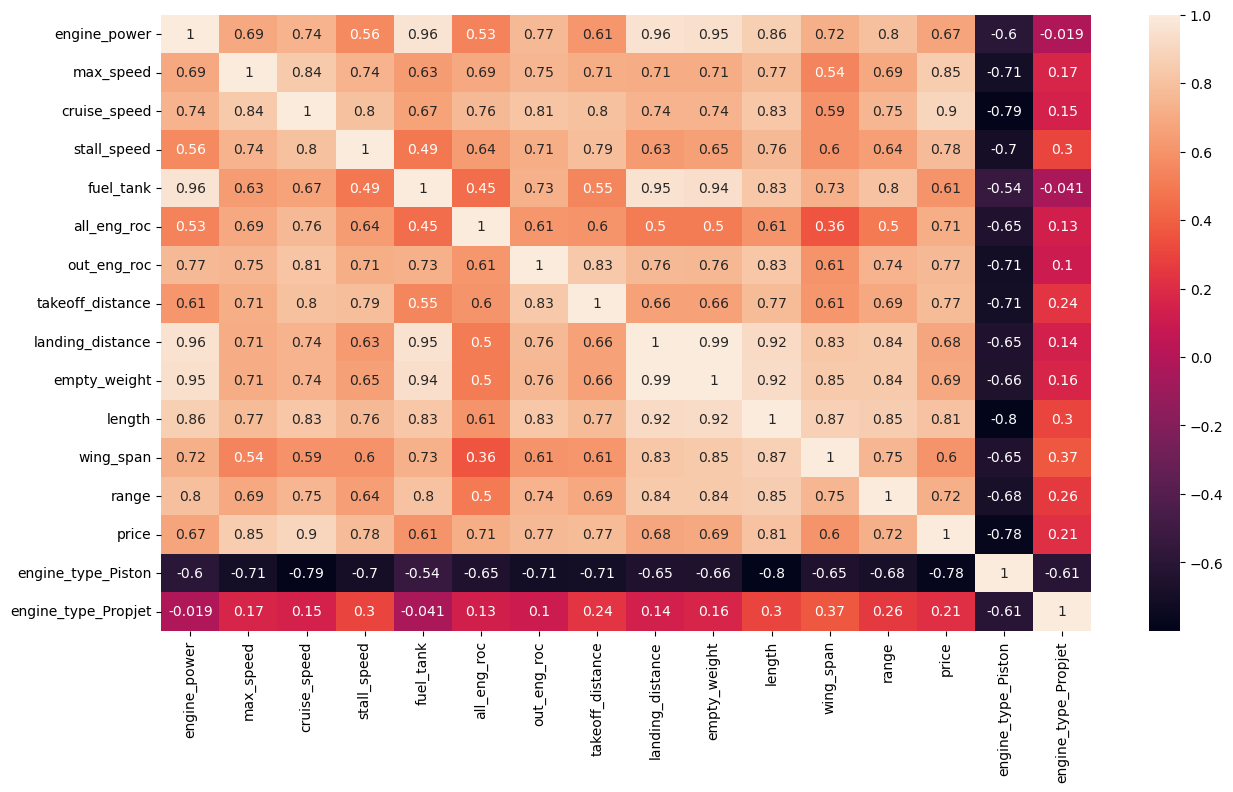

In [17]:
plt.figure(figsize=(15,8))
sns.heatmap(df_clean.corr(),annot=True)
plt.show()

In [18]:
#dependent and independent features
X = df_clean.drop(columns="price",axis=1)
y = df_clean["price"]

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
regression = LinearRegression()

In [22]:
regression.fit(X_train,y_train)

LinearRegression()

In [23]:
y_pred = regression.predict(X_test)

In [24]:
y_pred

array([2073628.21007983, 3014614.78526669, 2102593.51340053,
       1897259.45361263, 4427946.21104724, 2609516.90341283,
       2996483.97729479, 1942299.34937272, 2147082.0752255 ,
       1758879.66804271, 1790131.58975633, 1972816.35394777,
       2295517.88588011, 4631314.95471977, 3229574.99245418,
       2595938.22377774, 2136624.6319522 , 1888695.00876008,
       1873574.99121171, 1350567.4278906 , 3628013.93463481,
       1811072.18149844, 1902232.80322342, 1408567.50607432,
       2715182.83894666, 1938631.89342518, 1689083.24332368,
       1817616.70410785, 1664181.91230029, 1767843.5580048 ,
       3279876.27183004, 1609705.41261648, 1883806.28470514,
       4542703.48977784, 1426433.43995469, 4506832.02451154,
       2726050.65788304, 2841737.47807707, 4390335.56096826,
       1930594.16437587, 2337890.59902166, 1783386.8302407 ,
       2122315.23340206, 3385971.33263067, 1829548.25753538,
       2182369.83251601, 1864538.24707189, 1269396.01557414,
       2496530.90868604,

In [25]:
score = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
print(f"R2 score: {score}, MAE: {mae}, MSE: {mse}")

R2 score: 0.8508604070752233, MAE: 270588.69714301627, MSE: 132898610209.68465


<Figure size 1500x800 with 0 Axes>

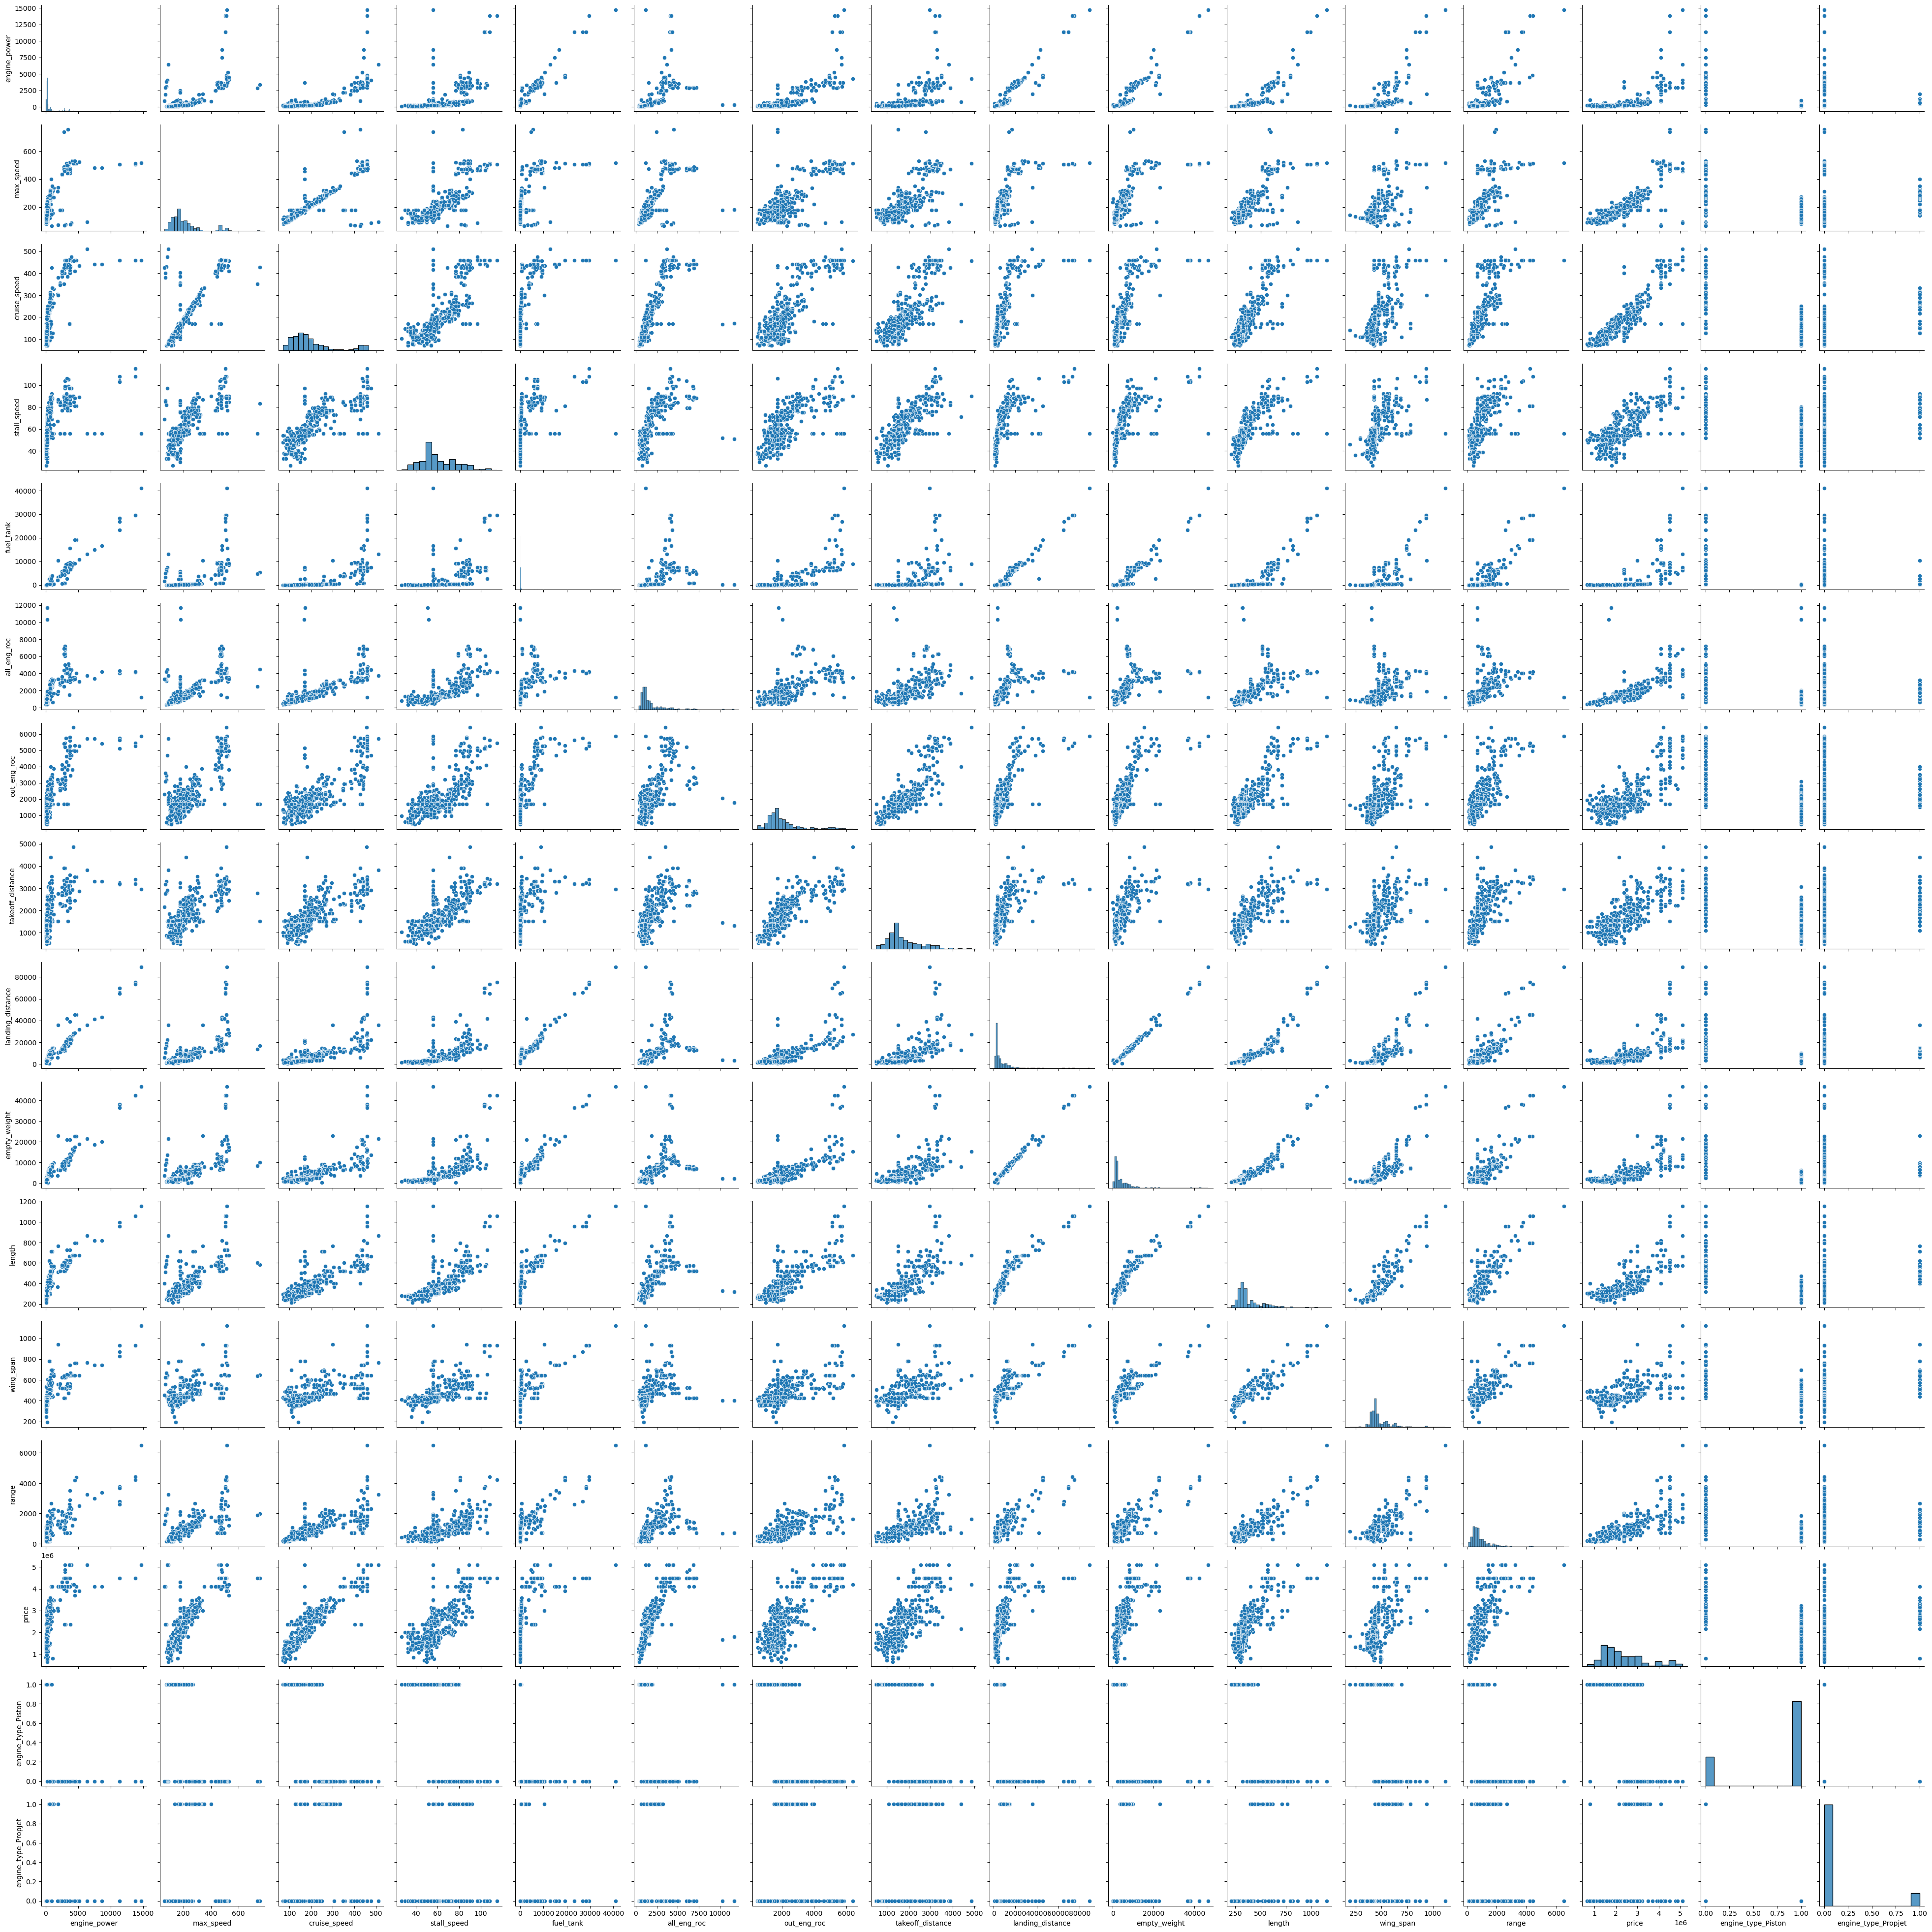

In [26]:
plt.figure(figsize=(15,8))
sns.pairplot(data=df_clean)
plt.show()